 # Bank Marketing Classification

                    
## Problem Statement:.

The goal of this project is to predict whether a bank customer will subscribe to a term deposit based on demographic and campaign-related features.

## Dataset: 


 This project uses the Bank Marketing dataset from the UCI Machine Learning Repository.
 The dataset contains information about customers contacted during marketing campaigns.

## Part A: Data Loading & Initial Exploration

In [39]:

import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("../data/bank-full.csv", sep=';')

# Check dataset shape
print("Dataset shape:", df.shape)

# Show first 5 rows
df.head()



Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [91]:
df.shape


(45211, 17)

In [93]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [97]:
df.isnull().sum()


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [99]:
df['y'].value_counts()


y
no     39922
yes     5289
Name: count, dtype: int64

## Part B: Exploratory Data Analysis (EDA)
This section explores the distribution of variables and their relationship with the target variable.

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns


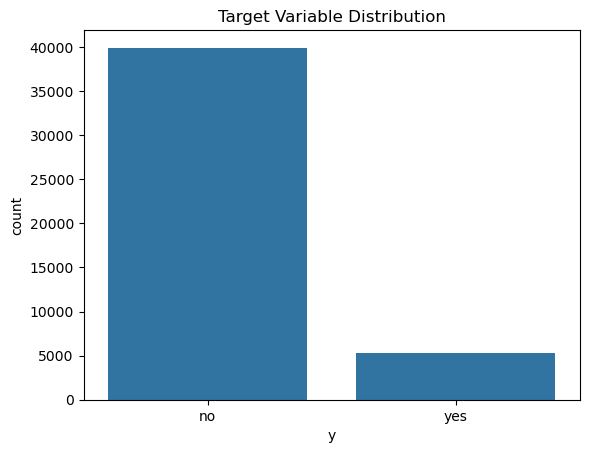

In [42]:
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution")
plt.show()


Telling us how many said yes and how many said no and we can clearly see around 50k said no .And our data is imbalanced

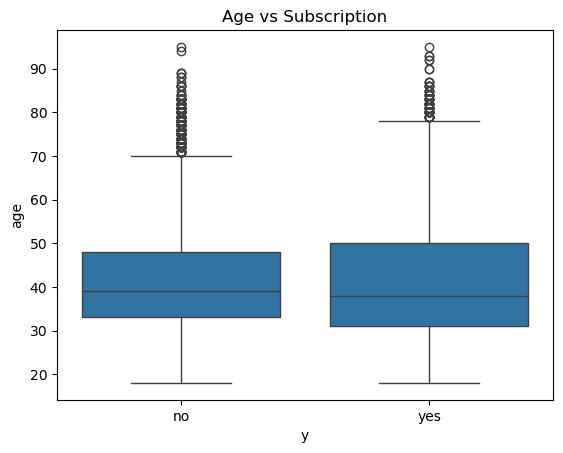

In [44]:
sns.boxplot(x='y', y='age', data=df)
plt.title("Age vs Subscription")
plt.show()


Age factor on yes or no but we can see there is no such greate diffrence between both 

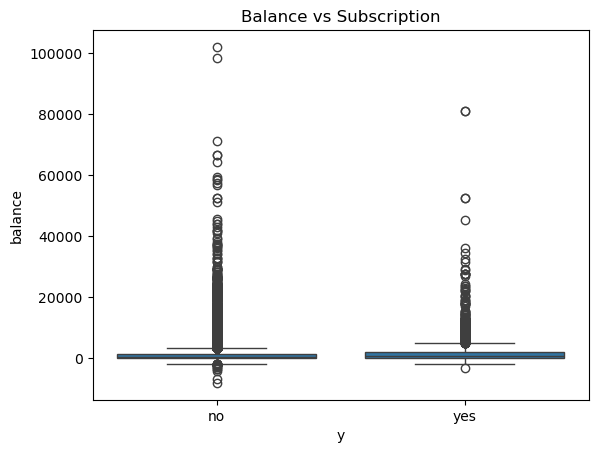

In [46]:
sns.boxplot(x='y', y='balance', data=df)
plt.title("Balance vs Subscription")
plt.show()


People with more money are more willing to subscribe, so balance is an important feature.
so it is an important feature

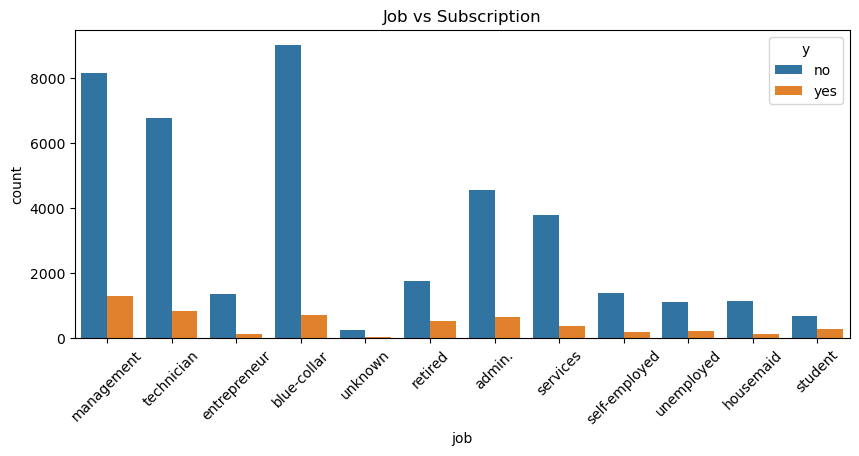

In [48]:
plt.figure(figsize=(10,4))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=45)
plt.title("Job vs Subscription")
plt.show()


Some jobs (like management, retired, student) have higher “yes” rates

Other jobs (like blue-collar, services) mostly say “no”

Job type clearly affects customer behavior

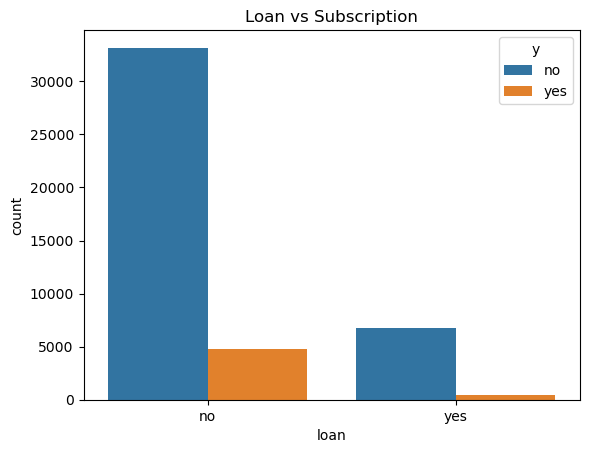

In [50]:
sns.countplot(x='loan', hue='y', data=df)
plt.title("Loan vs Subscription")
plt.show()


Customers without a personal loan say “yes” more often

Customers with a loan mostly say “no”

Having a loan reduces the likelihood of subscription

## Part C:Data Cleaning & Preprocessing
This section handles missing values, encoding of categorical features, and feature scaling.

In [95]:
# Column names
print("Columns:\n", df.columns.tolist())


# Target variable distribution
print("\nTarget value counts:")
print(df['y'].value_counts())


Columns:
 ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Target value counts:
y
no     39922
yes     5289
Name: count, dtype: int64


In [54]:
# Check how many 'unknown' values exist
(df == 'unknown').sum().sort_values(ascending=False)

poutcome     36959
contact      13020
education     1857
job            288
month            0
previous         0
pdays            0
campaign         0
duration         0
age              0
day              0
loan             0
housing          0
balance          0
default          0
marital          0
y                0
dtype: int64

We will treat "unknown" as a category, NOT drop them.

Reason: dropping rows would remove real customer data and reduce sample size

In [56]:
# Separate features and target
X = df.drop('y', axis=1)
y = df['y']

In [57]:
# Convert categorical text to numbers (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

# Check the new shape to make sure it worked
print("Original shape:", X.shape)
print("Encoded shape:", X_encoded.shape)

Original shape: (45211, 16)
Encoded shape: (45211, 42)


In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)

## Baseline Model
A logistic regression model is trained as a baseline to evaluate initial performance.

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [62]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [63]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[7781  204]
 [ 689  369]]
              precision    recall  f1-score   support

          no       0.92      0.97      0.95      7985
         yes       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



Improved Model
Class imbalance is addressed using class weighting to improve recall for the minority class.

In [65]:
model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model_balanced.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

## Part D: Model Comparison
Baseline and balanced models are compared using precision, recall, and F1-score.

In [67]:
y_pred_bal = model_balanced.predict(X_test)

print(confusion_matrix(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal))


[[6788 1197]
 [ 196  862]]
              precision    recall  f1-score   support

          no       0.97      0.85      0.91      7985
         yes       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043



| Metric          | Baseline LR | Balanced LR |
| --------------- | ----------- | ----------- |
| Accuracy        | 0.90        | 0.85        |
| Recall (yes)    | 0.35        | 0.81        |
| Precision (yes) | 0.64        | 0.42        |
| F1-score (yes)  | 0.45        | 0.55     

 Increasing recall led to more false positives, which is acceptable for a marketing campaign where missing potential subscribers is costlier than contacting uninterested customers.uracy.





The dataset was highly imbalanced, causing the baseline logistic regression model to favor the majority class.
To address this, class weighting was applied during training.
This significantly improved recall for the minority class (“yes”).
Although overall accuracy decreased slightly, the balanced model provides more meaningful predictions.
Therefore, the balanced logistic regression model is preferred for this task.


## Conclusion
The balanced model provides more meaningful predictions despite a slight decrease in overall accuracy.